In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 固定随机种子，让 DataLoader 的 shuffle、模型初始化都可复现
# 不固定的话，每次重跑训练曲线会略有差异，对比式容易混淆
torch.manual_seed(42)

# 设置字体支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 支持负号显示

# 定义数据集的预处理方式
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为张量
    transforms.Normalize((0.1307,), (0.3081,))  
])

# 第一次跑会自动下载数据集，之后会从本地读取
train_set = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader 把数据切成 batch
train_loader = DataLoader(dataset=train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(dataset=test_set, batch_size=256, shuffle=False)

print(f'训练集：{len(train_set)}张')
print(f'测试集：{len(test_set)}张')
print(f'每张图：{train_set[0][0].shape}(通道 × 高 × 宽)')

训练集：60000张
测试集：10000张
每张图：torch.Size([1, 28, 28])(通道 × 高 × 宽)


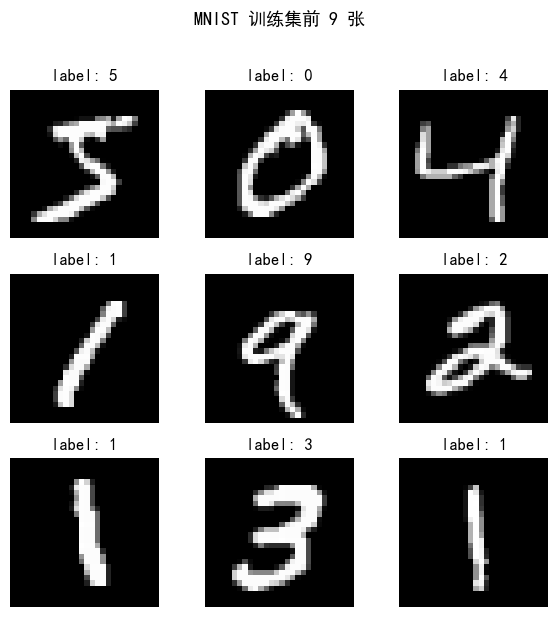

In [2]:
# 取9张样本看一下
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_set[i]
    ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')  
    ax.set_title(f'label: {label}', fontsize=12)
    ax.axis('off')
plt.suptitle('MNIST 训练集前 9 张', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
torch.manual_seed(42)  # 固定随机种子，让模型初始化可复现

W1 = (torch.randn(784, 128) * (2.0 / 784) ** 0.5).requires_grad_()  # 输入层到隐藏层的权重
b1 = torch.zeros(128, requires_grad=True)  # 隐藏层的偏置

W2 = (torch.randn(128, 10) * (2.0 / 128) ** 0.5).requires_grad_()  # 隐藏层到输出层的权重
b2 = torch.zeros(10, requires_grad=True)  # 输出层的偏置

# 把参数放在一起，方便优化器统一更新
params = [W1, b1, W2, b2]
lr = 0.1  # 学习率

print(f'网络共 {sum(p.numel() for p in params):,} 个参数')

网络共 101,770 个参数


In [4]:
train_losses, test_losses = [], []  # 记录训练集和测试集的损失

for epoch in range(5):
    running_loss = 0.0
    n_samples = 0

    for xb, yb in train_loader:
        # 前向传播
        xb = xb.view(-1, 784)  # 展平为 (batch_size, 784)

        h = F.relu(xb @ W1 + b1)  # 隐藏层输出
        logits = h @ W2 + b2  # 输出层输出

        # 计算损失
        loss = F.cross_entropy(logits, yb)

        # 反向传播
        loss.backward()    

        # 更新参数
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad
                p.grad.zero_()  # 清零梯度

        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    train_loss = running_loss / n_samples

    # 评估
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.view(-1, 784)
            h = F.relu(xb @ W1 + b1)
            logits = h @ W2 + b2
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
    test_accuracy = correct / len(test_set)
    
    train_losses.append(train_loss)
    test_losses.append(test_accuracy)
    print(f'epoch {epoch+1}/5, train_loss: {train_loss:.4f}, test_accuracy: {test_accuracy:.4f}')


epoch 1/5, train_loss: 0.2839, test_accuracy: 0.9486
epoch 2/5, train_loss: 0.1387, test_accuracy: 0.9647
epoch 3/5, train_loss: 0.1011, test_accuracy: 0.9674
epoch 4/5, train_loss: 0.0805, test_accuracy: 0.9712
epoch 5/5, train_loss: 0.0669, test_accuracy: 0.9736


In [5]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)  # 展平为 (batch_size, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

torch.manual_seed(42)  # 固定随机种子，让模型初始化可复现
model = SimpleMLP()
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

train_losses_v2, test_losses_v2 = [], []  # 记录训练集和测试集的损失

for epoch in range(5):
    model.train()
    running_loss = 0.0
    n_samples = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()  # 清零梯度
        logits = model(xb)  # 前向传播
        loss = loss_fn(logits, yb)  # 计算损失
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数

        running_loss += loss.item() * yb.size(0)
        n_samples += yb.size(0)

    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()

    train_losses_v2.append(running_loss / n_samples)
    test_losses_v2.append(correct / len(test_set))
    print(f'epoch {epoch+1}/5, train_loss: {train_losses_v2[-1]:.4f}, test_accuracy: {test_losses_v2[-1]:.4f}')

epoch 1/5, train_loss: 0.3329, test_accuracy: 0.9466
epoch 2/5, train_loss: 0.1606, test_accuracy: 0.9626
epoch 3/5, train_loss: 0.1147, test_accuracy: 0.9678
epoch 4/5, train_loss: 0.0914, test_accuracy: 0.9725
epoch 5/5, train_loss: 0.0738, test_accuracy: 0.9751


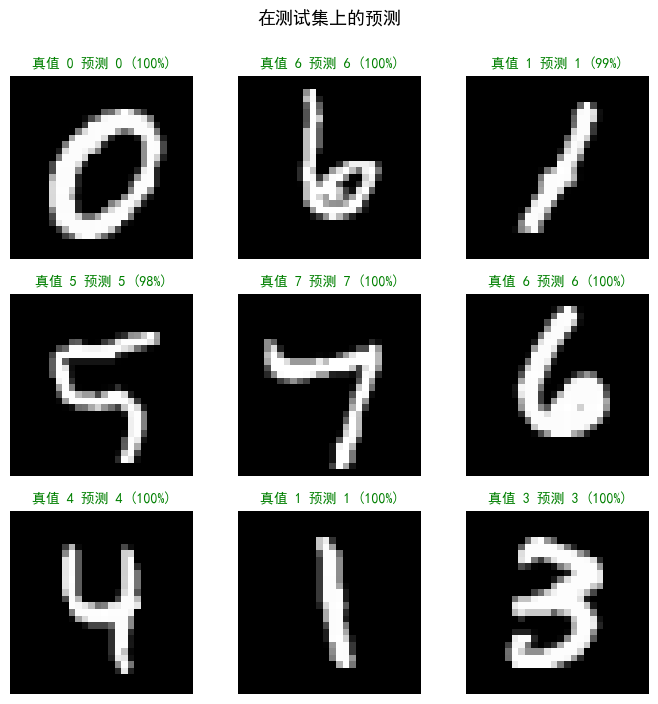

In [6]:
import random
random.seed(7)  # 固定随机种子，让模型初始化可复现
indices = random.sample(range(len(test_set)), 9)  # 随机选取9张测试集图片

model.eval()
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
with torch.no_grad():
    for ax, idx in zip(axes.flat, indices):
        img, label = test_set[idx]
        logits = model(img.unsqueeze(0))  # 增加 batch 维度
        probs = F.softmax(logits, dim=1)[0]
        pred = int(probs.argmax())  # 获取预测类别
        conf = float(probs[pred])

        ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')
        ok = (pred == label)
        ax.set_title(f'真值 {label} 预测 {pred} ({conf:.0%})',
                     fontsize=10, color=('green' if ok else 'red'))
        ax.axis('off')
    plt.suptitle('在测试集上的预测', fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()

In [ ]:
from IPython.display import display
from ipycanvas import Canvas
from ipywidgets import Button, HBox, VBox, Output
from PIL import Image

# 画板设置
CANVAS_SIZE= 560
LINE_WIDTH = max(8, CANVAS_SIZE // 14)  # 根据画板宽度动态设置线条宽度

canvas = Canvas(width=CANVAS_SIZE, height=CANVAS_SIZE, sync_image_data=True)
canvas.layout.width = f'{CANVAS_SIZE}px'
canvas.layout.height = f'{CANVAS_SIZE}px'
canvas.fill_style = 'black'
canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)  # 黑色背景
canvas.stroke_style = 'white'
canvas.line_width = LINE_WIDTH

brush = {'down': False, 'last': None}

def on_mouse_down(x, y):
    brush['down'] = True
    brush['last'] = (x, y)

def on_mouse_move(x, y):
    if brush['down'] and brush['last'] is not None:
        canvas.stroke_line(brush['last'][0], brush['last'][1], x, y)
        brush['last'] = (x, y)

def on_mouse_up(x, y):
    brush['down'] = False
    brush['last'] = None

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

output = Output()
btn_predict = Button(description='识别', button_style='primary', icon='check')
btn_clear = Button(description='清空', icon='trash')

def predict(_):
    output.clear_output()

    arr = canvas.get_image_data()
    if arr is None:
        with output:
            print('画板还没准备好，等 1 秒再试，或者现在画板上随便画一笔')
        return
    img = Image.fromarray(arr).convert('L')
    img = img.resize((28, 28), Image.LANCZOS)
    arr28 = np.array(img, dtype=np.float32)/255.0

    x = (torch.from_numpy(arr28) - 0.1307) / 0.3081

    model.eval()
    with torch.no_grad():
        logits = model(x.unsqueeze(0))  # 增加 batch 维度
        probs = F.softmax(logits, dim=1)[0].numpy()
    pred = int(probs.argmax())

    with output:
        fig, ax = plt.subplots(1, 2, figsize=(9, 3))
        ax[0].imshow(arr28, cmap='gray')
        ax[0].set_title('模型看到的（28 × 28）', fontsize=12)
        ax[0].axis('off')
        ax[1].bar(range(10), probs,
                  color=['coral' if i == pred else 'lightsteelblue' for i in range(10)])
        ax[1].set_xticks(range(10))
        ax[1].set_xlabel('类别')
        ax[1].set_ylim(0, 1)
        ax[1].set_title(f'模型预测 {pred}，置信度 {probs[pred]:.1%}', fontsize=12)
        ax[1].grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

def clear_canvas(_):
    canvas.clear()
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
    output.clear_output()

btn_predict.on_click(predict)
btn_clear.on_click(clear_canvas)

container = VBox(
    [canvas, HBox([btn_predict, btn_clear]), output],
    layout={'width': f'{CANVAS_SIZE+20}px', 'align_items': 'flex-start'},
    )
display(container)